# AutoSPECTRA — Week 2 Notebook
## Dataset Acquisition, DLC-Aware Parsing, Data Audit and Initial EDA

**Module:** Advanced Artificial Intelligence Projects in Data Science (55-710603)  
**Project:** AutoSPECTRA — Deep-Learning Intrusion Detection for the Connected Car  
**Group:** 7  
**Week:** 2 of 8

This notebook records the second weekly GitHub development milestone. It focuses only on the dataset foundation needed before window generation and model training.

## Week 2 Scope

- Locate and validate the HCRL Car-Hacking dataset files.
- Implement a memory-efficient DLC-aware CAN parser.
- Convert timestamps, hexadecimal CAN IDs and payload bytes.
- Audit source-file size, row count, flags, DLC, CAN IDs and payload values.
- Produce initial exploratory data analysis.
- Export small Week 2 evidence files for GitHub.
- Keep the raw dataset, processed caches and trained models outside the repository.

## Team Contributions

| Member | Name | Role | Week 2 Contribution |
|---|---|---|---|
| 1 | Amit Das | Data Pipeline & Integration Lead | Located the HCRL source files, implemented the chunked DLC-aware parser, completed the source-level data audit and integrated the Week 2 notebook |
| 2 | Aahmad Sayeed | EDA & Visual Representation Lead | Reviewed CAN-ID, DLC, payload and timing visualisations and documented requirements for the later recurrence-image representation |
| 3 | Maheswari Kamireddy | Sequence Data Lead | Verified chronological ordering, payload padding and sequence-ready fields required for the later LSTM and autoencoder models |
| 4 | Miftha Thahniyath | Reporting & Metadata Lead | Reviewed the metadata and audit outputs required for later incident-report generation, Flask display and demonstration evidence |
| 5 | Nagireddy Nakka | Ethics & Documentation Lead | Documented responsible data handling, dataset limitations, human-oversight requirements and Week 2 GitHub evidence |

## Eight-Week Development Plan

| Week | Technical Evidence |
|---|---|
| Week 1 | Repository setup, research problem, system architecture, roles and initial ethics |
| **Week 2** | **Dataset acquisition, DLC-aware parsing, data audit and initial EDA** |
| Week 3 | Windowing, chronological splitting, leakage controls and feature representations |
| Week 4 | Logistic Regression, Random Forest, Extra Trees and XGBoost baselines |
| Week 5 | Recurrence-image encoder and CNN |
| Week 6 | Bidirectional LSTM and LSTM autoencoder |
| Week 7 | Fusion, calibration, ablation, latency, error analysis and responsible AI |
| Week 8 | Incident reporting, Flask application, live demonstration and final reproducibility package |

## Week 2 Boundary

This notebook does not train the final machine-learning or deep-learning models. It does not report final accuracy, macro-F1, confusion matrices, fusion results or Flask deployment. Those items are reserved for later weekly pushes.

## Kaggle instructions

1. Open Kaggle and create a notebook.
2. Choose **Add Input**.
3. Attach: `pranavjha24/car-hacking-dataset`.
4. Run all cells.
5. Outputs are written to:

```text
/kaggle/working/autospectra_week02_outputs
```

The notebook processes the source files in chunks so the complete dataset does not need to be held in RAM.

In [5]:
# 1. Imports, reproducibility and output folders

import os
import json
import math
import random
import platform
import warnings
import zipfile
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

OUTPUT_DIR = Path("/kaggle/working/autospectra_week02_outputs")
PLOT_DIR = OUTPUT_DIR / "plots"
REPORT_DIR = OUTPUT_DIR / "reports"

for directory in (OUTPUT_DIR, PLOT_DIR, REPORT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Output directory:", OUTPUT_DIR)

Python: 3.12.13
NumPy: 2.0.2
Pandas: 2.3.3
Output directory: /kaggle/working/autospectra_week02_outputs


In [6]:
# 2. Week 2 configuration

CHUNK_SIZE = 400_000
MAX_SAMPLE_ROWS_PER_CAPTURE = 50_000
SAMPLE_ROWS_PER_CHUNK = 4_000

SOURCE_FILES = {
    "DoS": "DoS_dataset.csv",
    "Fuzzy": "Fuzzy_dataset.csv",
    "Gear": "gear_dataset.csv",
    "RPM": "RPM_dataset.csv",
}

RAW_COLUMNS = ["Timestamp", "CAN_ID", "DLC"] + [f"X{i}" for i in range(9)]
PAYLOAD_COLUMNS = [f"DATA_{i}" for i in range(8)]

print("Required source files:")
for capture, filename in SOURCE_FILES.items():
    print(f"  {capture:>5}: {filename}")

Required source files:
    DoS: DoS_dataset.csv
  Fuzzy: Fuzzy_dataset.csv
   Gear: gear_dataset.csv
    RPM: RPM_dataset.csv


## 3. Locate the Kaggle input files

The project uses four labelled attack captures:

- DoS
- Fuzzy injection
- Gear spoofing
- RPM spoofing

Each attack capture also contains legitimate frames marked `R`. The separate `normal_run_data.txt` is located when present but is not merged into this Week 2 audit because the authoritative five-class experiment derives Normal examples consistently from legitimate frames inside the four attack captures.

In [7]:
# 3. Dataset discovery

def locate_dataset_files(search_root="/kaggle/input"):
    found = {}
    optional_normal = None

    for root, _, files in os.walk(search_root):
        lower_to_original = {name.lower(): name for name in files}

        for capture, expected in SOURCE_FILES.items():
            if expected.lower() in lower_to_original:
                found[capture] = Path(root) / lower_to_original[expected.lower()]

        if "normal_run_data.txt" in lower_to_original:
            optional_normal = Path(root) / lower_to_original["normal_run_data.txt"]

    missing = sorted(set(SOURCE_FILES) - set(found))
    if missing:
        raise FileNotFoundError(
            "Missing required capture files for: "
            + ", ".join(missing)
            + ". Attach Kaggle dataset 'pranavjha24/car-hacking-dataset'."
        )

    return found, optional_normal


DATA_FILES, OPTIONAL_NORMAL_FILE = locate_dataset_files()

file_table = pd.DataFrame([
    {
        "Capture": capture,
        "Filename": path.name,
        "Size_MB": round(path.stat().st_size / (1024 ** 2), 2),
        "Path": str(path),
    }
    for capture, path in DATA_FILES.items()
]).sort_values("Capture").reset_index(drop=True)

display(file_table)
print("Optional independent normal capture:", OPTIONAL_NORMAL_FILE)

file_table.to_csv(REPORT_DIR / "week02_dataset_file_manifest.csv", index=False)

,Capture,Filename,Size_MB,Path
0,DoS,DoS_dataset.csv,181.25,/kaggle/input/datasets/pranavjha24/car-hacking...
1,Fuzzy,Fuzzy_dataset.csv,189.32,/kaggle/input/datasets/pranavjha24/car-hacking...
2,Gear,gear_dataset.csv,219.65,/kaggle/input/datasets/pranavjha24/car-hacking...
3,RPM,RPM_dataset.csv,228.48,/kaggle/input/datasets/pranavjha24/car-hacking...


Optional independent normal capture: /kaggle/input/datasets/pranavjha24/car-hacking-dataset/normal_run_data.txt


## 4. DLC-aware parser

A standard fixed-position parser is unsafe for this dataset. The final `R` or `T` flag appears immediately after the number of payload bytes specified by DLC.

Examples:

```text
DLC = 8 → 8 payload values, then Flag
DLC = 2 → 2 payload values, then Flag
```

The parser below:

1. reads the flexible raw fields;
2. converts timestamps and DLC;
3. converts hexadecimal CAN IDs and payload bytes;
4. uses DLC to identify valid payload positions;
5. uses DLC to locate the final flag;
6. pads absent payload positions with zero only for a uniform audit table.

In [8]:
# 4. Fast hexadecimal lookup tables

HEX_BYTE_MAP = {}
for value in range(256):
    for key in {f"{value:02x}", f"{value:02X}", f"{value:x}", f"{value:X}"}:
        HEX_BYTE_MAP[key] = value

CAN_ID_MAP = {}
for value in range(0x800):
    for key in {
        f"{value:04x}", f"{value:04X}",
        f"{value:03x}", f"{value:03X}",
        f"{value:x}", f"{value:X}",
    }:
        CAN_ID_MAP[key] = value


def convert_chunk(chunk):
    '''
    Convert a flexible-width raw HCRL chunk to compact numeric arrays.

    Returns:
        timestamps: float64
        can_ids: uint16
        dlc: uint8
        payload: uint8 array with shape (rows, 8)
        is_attack: boolean, True for T and False for R
    '''
    original_rows = len(chunk)

    chunk = chunk.dropna(
        subset=["Timestamp", "CAN_ID", "DLC"]
    ).copy()

    timestamps = pd.to_numeric(
        chunk["Timestamp"], errors="coerce"
    ).to_numpy(np.float64)

    dlc = (
        pd.to_numeric(chunk["DLC"], errors="coerce")
        .fillna(0)
        .clip(0, 8)
        .to_numpy(np.uint8)
    )

    can_text = chunk["CAN_ID"].astype(str).str.strip()
    can_series = can_text.map(CAN_ID_MAP)

    missing_ids = can_series.isna()
    if missing_ids.any():
        def safe_hex_to_int(value):
            try:
                return int(str(value), 16)
            except (TypeError, ValueError):
                return np.nan

        can_series.loc[missing_ids] = (
            can_text.loc[missing_ids].map(safe_hex_to_int)
        )

    can_ids = (
        can_series
        .fillna(0)
        .clip(0, 0x7FF)
        .to_numpy(np.uint16)
    )

    payload = np.zeros((len(chunk), 8), dtype=np.uint8)

    for byte_index in range(8):
        text = chunk[f"X{byte_index}"].astype(str).str.strip()
        numeric = (
            text.map(HEX_BYTE_MAP)
            .fillna(0)
            .clip(0, 255)
            .to_numpy(np.uint16)
        )

        valid_byte = dlc > byte_index
        payload[valid_byte, byte_index] = (
            numeric[valid_byte].astype(np.uint8)
        )

    is_attack = np.zeros(len(chunk), dtype=bool)

    for dlc_value in range(9):
        mask = dlc == dlc_value
        if not mask.any():
            continue

        flag_text = (
            chunk[f"X{dlc_value}"]
            .astype(str)
            .str.strip()
            .str.upper()
        )

        is_attack[mask] = (
            flag_text[mask].eq("T").to_numpy()
        )

    valid_timestamp = np.isfinite(timestamps)

    dropped_rows = original_rows - int(valid_timestamp.sum())

    return (
        timestamps[valid_timestamp],
        can_ids[valid_timestamp],
        dlc[valid_timestamp],
        payload[valid_timestamp],
        is_attack[valid_timestamp],
        dropped_rows,
    )

## 5. Chunked audit

The audit calculates source-level statistics without storing all messages:

- valid row count;
- normal and attack counts;
- timestamp range;
- capture duration;
- DLC distribution;
- CAN-ID diversity;
- most frequent CAN IDs;
- payload-byte means;
- inter-arrival-time sample;
- a bounded reproducible sample for plots.

This Week 2 audit does not create model windows or train a classifier.

In [9]:
# 5. Process one source capture in chunks

def update_counter_from_array(counter, values):
    unique, counts = np.unique(values, return_counts=True)
    counter.update({
        int(value): int(count)
        for value, count in zip(unique, counts)
    })


def audit_capture(capture_name, path):
    row_count = 0
    dropped_rows = 0
    attack_count = 0
    timestamp_min = np.inf
    timestamp_max = -np.inf

    dlc_counter = Counter()
    can_counter_all = Counter()
    can_counter_normal = Counter()
    can_counter_attack = Counter()

    payload_sum = np.zeros(8, dtype=np.float64)
    payload_sq_sum = np.zeros(8, dtype=np.float64)
    payload_valid_count = np.zeros(8, dtype=np.int64)

    iat_sample_parts = []
    sample_parts = []
    previous_timestamp = None

    reader = pd.read_csv(
        path,
        names=RAW_COLUMNS,
        header=None,
        dtype=str,
        chunksize=CHUNK_SIZE,
        engine="c",
        on_bad_lines="skip",
    )

    for chunk_number, chunk in enumerate(reader, start=1):
        (
            timestamps,
            can_ids,
            dlc,
            payload,
            is_attack,
            dropped,
        ) = convert_chunk(chunk)

        if len(timestamps) == 0:
            continue

        row_count += len(timestamps)
        dropped_rows += dropped
        attack_count += int(is_attack.sum())

        timestamp_min = min(timestamp_min, float(timestamps.min()))
        timestamp_max = max(timestamp_max, float(timestamps.max()))

        update_counter_from_array(dlc_counter, dlc)
        update_counter_from_array(can_counter_all, can_ids)
        update_counter_from_array(can_counter_normal, can_ids[~is_attack])
        update_counter_from_array(can_counter_attack, can_ids[is_attack])

        for byte_index in range(8):
            valid = dlc > byte_index
            values = payload[valid, byte_index].astype(np.float64)
            payload_sum[byte_index] += values.sum()
            payload_sq_sum[byte_index] += np.square(values).sum()
            payload_valid_count[byte_index] += len(values)

        # Inter-arrival times, including the boundary between chunks.
        if previous_timestamp is None:
            combined = timestamps
        else:
            combined = np.concatenate([[previous_timestamp], timestamps])

        deltas = np.diff(combined)
        deltas = deltas[deltas >= 0]

        if len(deltas):
            take = min(5_000, len(deltas))
            indices = np.linspace(0, len(deltas) - 1, take, dtype=int)
            iat_sample_parts.append(deltas[indices])

        previous_timestamp = float(timestamps[-1])

        # Bounded deterministic sample for EDA.
        take = min(SAMPLE_ROWS_PER_CHUNK, len(timestamps))
        rng = np.random.default_rng(SEED + chunk_number)
        selected = rng.choice(len(timestamps), size=take, replace=False)

        sample = pd.DataFrame({
            "Capture": capture_name,
            "Timestamp": timestamps[selected],
            "CAN_ID_Decimal": can_ids[selected].astype(int),
            "CAN_ID_Hex": [f"0x{value:03X}" for value in can_ids[selected]],
            "DLC": dlc[selected].astype(int),
            "Flag": np.where(is_attack[selected], "T", "R"),
            "Traffic_Class": np.where(is_attack[selected], capture_name, "Normal"),
        })

        for byte_index in range(8):
            sample[f"DATA_{byte_index}"] = payload[selected, byte_index].astype(int)

        sample_parts.append(sample)

        print(
            f"{capture_name}: processed chunk {chunk_number}; "
            f"valid rows so far = {row_count:,}"
        )

    if row_count == 0:
        raise RuntimeError(f"No valid rows were parsed from {path}")

    sampled = pd.concat(sample_parts, ignore_index=True)

    if len(sampled) > MAX_SAMPLE_ROWS_PER_CAPTURE:
        sampled = sampled.sample(
            MAX_SAMPLE_ROWS_PER_CAPTURE,
            random_state=SEED,
        ).sort_values("Timestamp").reset_index(drop=True)

    iat_sample = (
        np.concatenate(iat_sample_parts)
        if iat_sample_parts
        else np.array([], dtype=float)
    )

    if len(iat_sample) > 100_000:
        rng = np.random.default_rng(SEED)
        iat_sample = rng.choice(
            iat_sample,
            size=100_000,
            replace=False,
        )

    means = payload_sum / np.maximum(payload_valid_count, 1)
    variances = (
        payload_sq_sum / np.maximum(payload_valid_count, 1)
        - np.square(means)
    )
    stds = np.sqrt(np.clip(variances, 0, None))

    summary = {
        "Capture": capture_name,
        "Rows": int(row_count),
        "Dropped_Invalid_Timestamp_Rows": int(dropped_rows),
        "Normal_Rows": int(row_count - attack_count),
        "Attack_Rows": int(attack_count),
        "Attack_Percent": float(100 * attack_count / row_count),
        "Timestamp_Min": float(timestamp_min),
        "Timestamp_Max": float(timestamp_max),
        "Duration_Seconds": float(timestamp_max - timestamp_min),
        "Unique_CAN_IDs": int(len(can_counter_all)),
    }

    return {
        "summary": summary,
        "sample": sampled,
        "iat_sample": iat_sample,
        "dlc_counter": dlc_counter,
        "can_counter_all": can_counter_all,
        "can_counter_normal": can_counter_normal,
        "can_counter_attack": can_counter_attack,
        "payload_mean": means,
        "payload_std": stds,
        "payload_valid_count": payload_valid_count,
    }

In [10]:
# 6. Audit all four captures

AUDITS = {}

for capture_name, path in DATA_FILES.items():
    print("\n" + "=" * 90)
    print(f"AUDITING {capture_name}: {path.name}")
    print("=" * 90)

    AUDITS[capture_name] = audit_capture(
        capture_name,
        path,
    )

summary_df = pd.DataFrame([
    AUDITS[capture]["summary"]
    for capture in SOURCE_FILES
])

display(summary_df)

summary_df.to_csv(
    REPORT_DIR / "week02_capture_summary.csv",
    index=False,
)


AUDITING DoS: DoS_dataset.csv
DoS: processed chunk 1; valid rows so far = 400,000
DoS: processed chunk 2; valid rows so far = 800,000
DoS: processed chunk 3; valid rows so far = 1,200,000
DoS: processed chunk 4; valid rows so far = 1,600,000
DoS: processed chunk 5; valid rows so far = 2,000,000
DoS: processed chunk 6; valid rows so far = 2,400,000
DoS: processed chunk 7; valid rows so far = 2,800,000
DoS: processed chunk 8; valid rows so far = 3,200,000
DoS: processed chunk 9; valid rows so far = 3,600,000
DoS: processed chunk 10; valid rows so far = 3,665,771

AUDITING Fuzzy: Fuzzy_dataset.csv
Fuzzy: processed chunk 1; valid rows so far = 400,000
Fuzzy: processed chunk 2; valid rows so far = 800,000
Fuzzy: processed chunk 3; valid rows so far = 1,200,000
Fuzzy: processed chunk 4; valid rows so far = 1,600,000
Fuzzy: processed chunk 5; valid rows so far = 2,000,000
Fuzzy: processed chunk 6; valid rows so far = 2,400,000
Fuzzy: processed chunk 7; valid rows so far = 2,800,000
Fuzzy: pr

,Capture,Rows,Dropped_Invalid_Timestamp_Rows,Normal_Rows,Attack_Rows,Attack_Percent,Timestamp_Min,Timestamp_Max,Duration_Seconds,Unique_CAN_IDs
0,DoS,3665771,0,3078250,587521,16.027215,1.478198e+09,1.478201e+09,2832.669517,27
1,Fuzzy,3838860,0,3347013,491847,12.812319,1.478196e+09,1.478201e+09,5487.155067,2048
2,Gear,4443142,0,3845890,597252,13.442109,1.478193e+09,1.478201e+09,8019.002378,26
3,RPM,4621702,0,3966805,654897,14.170040,1.478191e+09,1.478201e+09,10179.013830,26


In [11]:
# 7. Combine bounded EDA samples and export them

eda_sample_df = pd.concat(
    [AUDITS[capture]["sample"] for capture in SOURCE_FILES],
    ignore_index=True,
)

print("EDA sample shape:", eda_sample_df.shape)
display(eda_sample_df.head())

eda_sample_df.to_csv(
    REPORT_DIR / "week02_eda_sample.csv",
    index=False,
)

EDA sample shape: (176000, 15)


,Capture,Timestamp,CAN_ID_Decimal,CAN_ID_Hex,DLC,Flag,Traffic_Class,DATA_0,DATA_1,DATA_2,DATA_3,DATA_4,DATA_5,DATA_6,DATA_7
0,DoS,1.478199e+09,790,0x316,8,R,Normal,5,34,104,9,34,33,0,111
1,DoS,1.478198e+09,320,0x140,8,R,Normal,0,0,0,0,22,34,34,71
2,DoS,1.478198e+09,672,0x2A0,8,R,Normal,68,0,154,29,151,2,189,0
3,DoS,1.478199e+09,790,0x316,8,R,Normal,5,34,108,9,34,33,0,111
4,DoS,1.478198e+09,672,0x2A0,8,R,Normal,4,0,154,29,151,2,189,0


# Part A — Week 2 Data-Quality Results and Visualisations

These plots describe the source data before model-specific windowing and splitting. Their purpose is to establish data quality, attack prevalence and behavioural differences—not to claim predictive performance.

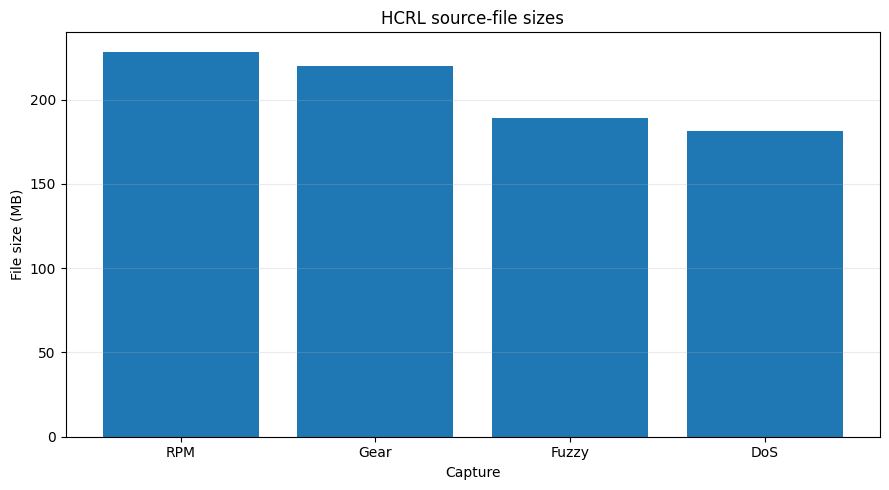

In [12]:
# EDA 1 — Source-file sizes

plot_df = file_table.sort_values("Size_MB", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(plot_df["Capture"], plot_df["Size_MB"])
ax.set_title("HCRL source-file sizes")
ax.set_xlabel("Capture")
ax.set_ylabel("File size (MB)")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(PLOT_DIR / "01_source_file_sizes.png", dpi=180)
plt.show()

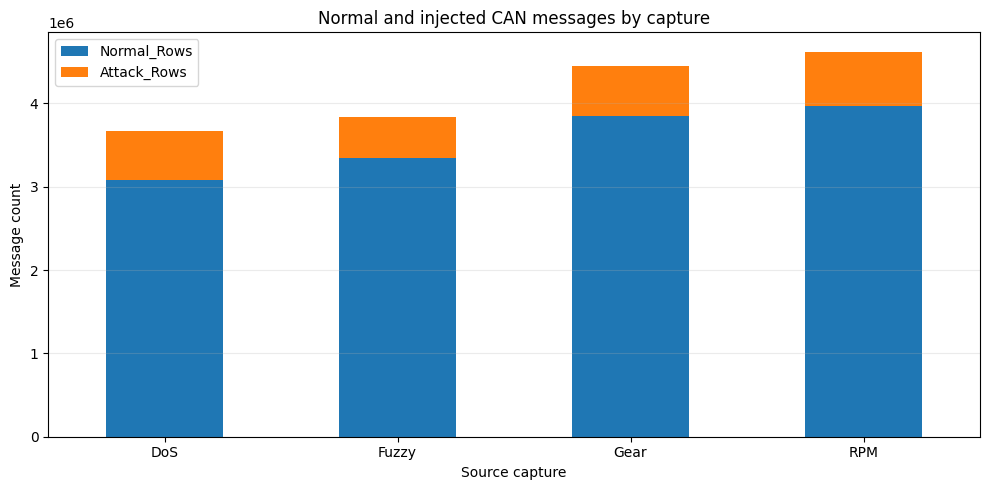

,Normal_Rows,Attack_Rows
Capture,,
DoS,3078250,587521
Fuzzy,3347013,491847
Gear,3845890,597252
RPM,3966805,654897


In [13]:
# EDA 2 — Normal and injected message counts by source capture

count_df = summary_df.set_index("Capture")[["Normal_Rows", "Attack_Rows"]]

fig, ax = plt.subplots(figsize=(10, 5))
count_df.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Normal and injected CAN messages by capture")
ax.set_xlabel("Source capture")
ax.set_ylabel("Message count")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(PLOT_DIR / "02_normal_attack_counts.png", dpi=180)
plt.show()

display(count_df)

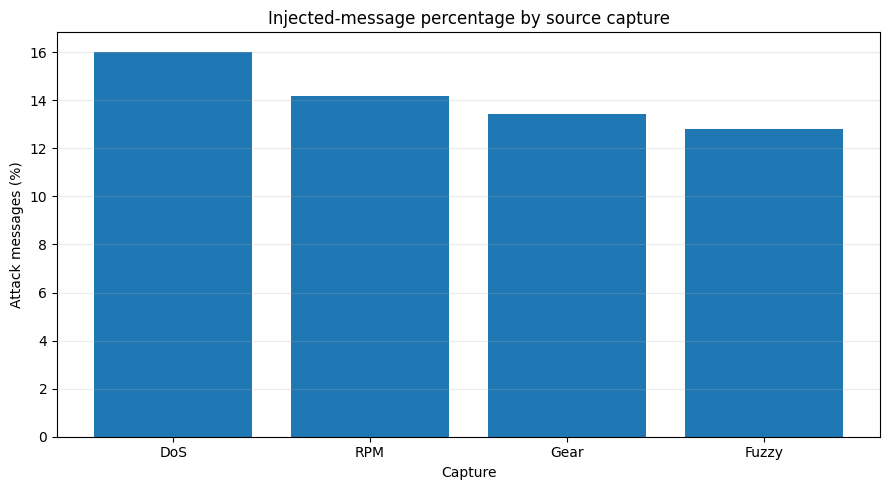

,Capture,Attack_Percent
0,DoS,16.027215
1,RPM,14.170040
2,Gear,13.442109
3,Fuzzy,12.812319


In [14]:
# EDA 3 — Attack-message percentage

plot_df = summary_df.sort_values("Attack_Percent", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(plot_df["Capture"], plot_df["Attack_Percent"])
ax.set_title("Injected-message percentage by source capture")
ax.set_xlabel("Capture")
ax.set_ylabel("Attack messages (%)")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(PLOT_DIR / "03_attack_percentage.png", dpi=180)
plt.show()

display(
    plot_df[["Capture", "Attack_Percent"]]
    .reset_index(drop=True)
)

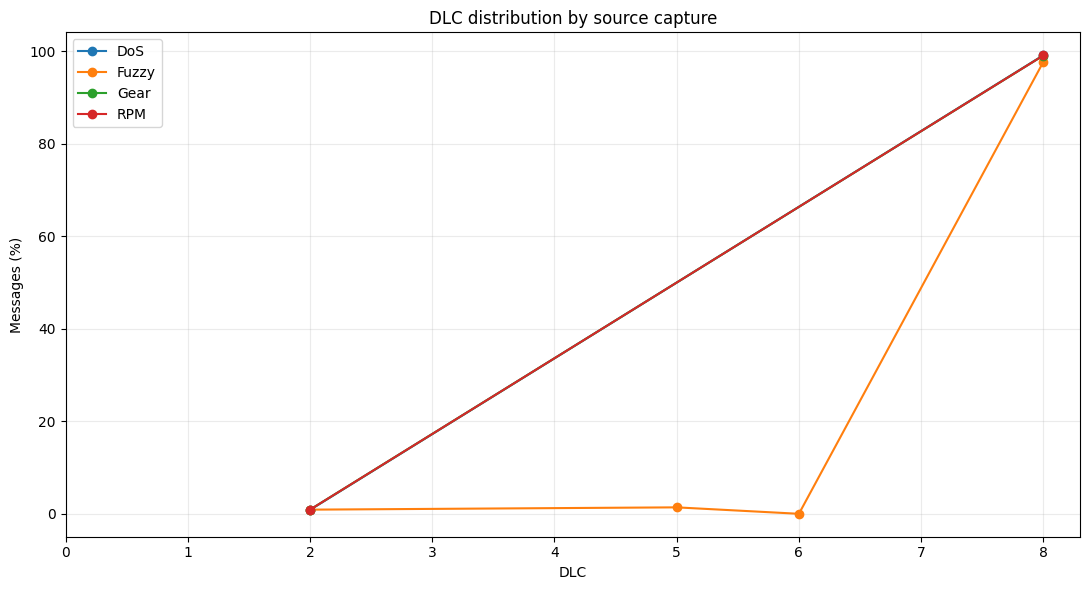

,Capture,DLC,Count,Percent
0,DoS,2,31188,0.850790
1,DoS,8,3634583,99.149210
2,Fuzzy,2,34382,0.895630
3,Fuzzy,5,53451,1.392366
4,Fuzzy,6,3,0.000078
5,Fuzzy,8,3751024,97.711925
6,Gear,2,40165,0.903977
7,Gear,8,4402977,99.096023
8,RPM,2,41476,0.897418
9,RPM,8,4580226,99.102582


In [15]:
# EDA 4 — DLC distribution by source capture

dlc_rows = []

for capture in SOURCE_FILES:
    total = sum(AUDITS[capture]["dlc_counter"].values())

    for dlc_value, count in sorted(AUDITS[capture]["dlc_counter"].items()):
        dlc_rows.append({
            "Capture": capture,
            "DLC": int(dlc_value),
            "Count": int(count),
            "Percent": 100 * count / total,
        })

dlc_df = pd.DataFrame(dlc_rows)

fig, ax = plt.subplots(figsize=(11, 6))

for capture in SOURCE_FILES:
    subset = dlc_df[dlc_df["Capture"] == capture]
    ax.plot(
        subset["DLC"],
        subset["Percent"],
        marker="o",
        label=capture,
    )

ax.set_title("DLC distribution by source capture")
ax.set_xlabel("DLC")
ax.set_ylabel("Messages (%)")
ax.set_xticks(range(9))
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "04_dlc_distribution.png", dpi=180)
plt.show()

display(dlc_df)

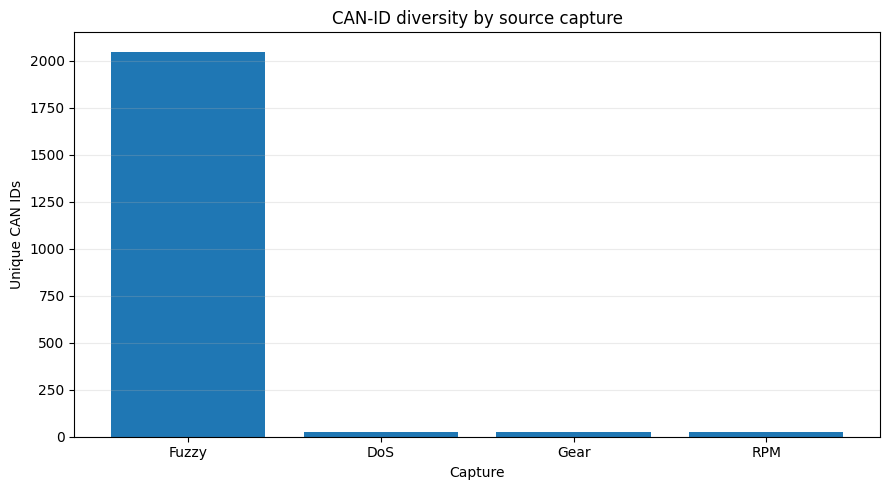

,Capture,Unique_CAN_IDs
1,Fuzzy,2048
0,DoS,27
2,Gear,26
3,RPM,26


In [16]:
# EDA 5 — Number of unique CAN IDs by capture

plot_df = summary_df.sort_values("Unique_CAN_IDs", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(plot_df["Capture"], plot_df["Unique_CAN_IDs"])
ax.set_title("CAN-ID diversity by source capture")
ax.set_xlabel("Capture")
ax.set_ylabel("Unique CAN IDs")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(PLOT_DIR / "05_unique_can_ids.png", dpi=180)
plt.show()

display(plot_df[["Capture", "Unique_CAN_IDs"]])

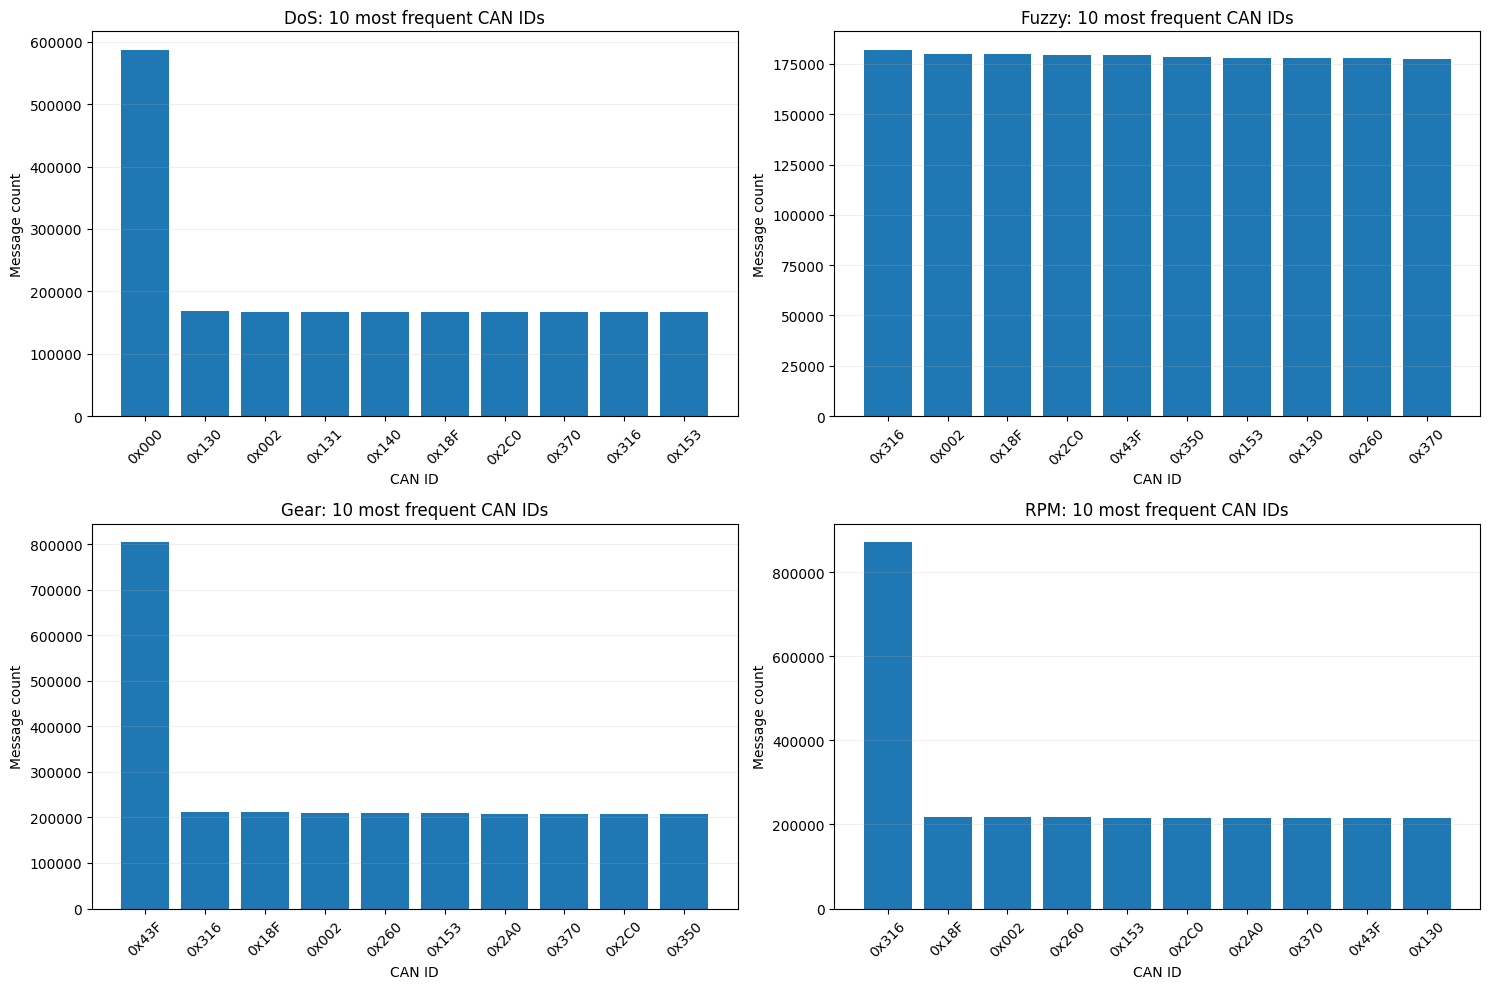

,Capture,Rank,CAN_ID_Decimal,CAN_ID_Hex,Count
0,DoS,1,0,0x000,587521
1,DoS,2,304,0x130,168118
2,DoS,3,2,0x002,167556
3,DoS,4,305,0x131,167016
4,DoS,5,320,0x140,167002
5,DoS,6,399,0x18F,166931
6,DoS,7,704,0x2C0,166713
7,DoS,8,880,0x370,166681
8,DoS,9,790,0x316,166631
9,DoS,10,339,0x153,166573


In [17]:
# EDA 6 — Top CAN IDs in each source capture

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

top_id_rows = []

for ax, capture in zip(axes, SOURCE_FILES):
    top_items = AUDITS[capture]["can_counter_all"].most_common(10)
    labels = [f"0x{can_id:03X}" for can_id, _ in top_items]
    counts = [count for _, count in top_items]

    ax.bar(labels, counts)
    ax.set_title(f"{capture}: 10 most frequent CAN IDs")
    ax.set_xlabel("CAN ID")
    ax.set_ylabel("Message count")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.2)

    for rank, (can_id, count) in enumerate(top_items, start=1):
        top_id_rows.append({
            "Capture": capture,
            "Rank": rank,
            "CAN_ID_Decimal": can_id,
            "CAN_ID_Hex": f"0x{can_id:03X}",
            "Count": count,
        })

plt.tight_layout()
plt.savefig(PLOT_DIR / "06_top_can_ids.png", dpi=180)
plt.show()

top_can_ids_df = pd.DataFrame(top_id_rows)
top_can_ids_df.to_csv(
    REPORT_DIR / "week02_top_can_ids.csv",
    index=False,
)
display(top_can_ids_df.head(20))

In [18]:
# EDA 7 — Dominant attack CAN IDs compared with normal CAN IDs

comparison_rows = []

for capture in SOURCE_FILES:
    normal_top = AUDITS[capture]["can_counter_normal"].most_common(5)
    attack_top = AUDITS[capture]["can_counter_attack"].most_common(5)

    for traffic, items in [("Normal", normal_top), ("Attack", attack_top)]:
        for rank, (can_id, count) in enumerate(items, start=1):
            comparison_rows.append({
                "Capture": capture,
                "Traffic": traffic,
                "Rank": rank,
                "CAN_ID_Hex": f"0x{can_id:03X}",
                "Count": count,
            })

normal_attack_id_df = pd.DataFrame(comparison_rows)
display(normal_attack_id_df)

normal_attack_id_df.to_csv(
    REPORT_DIR / "week02_normal_attack_top_ids.csv",
    index=False,
)

,Capture,Traffic,Rank,CAN_ID_Hex,Count
0,DoS,Normal,1,0x130,168118
1,DoS,Normal,2,0x002,167556
2,DoS,Normal,3,0x131,167016
3,DoS,Normal,4,0x140,167002
4,DoS,Normal,5,0x18F,166931
5,DoS,Attack,1,0x000,587521
6,Fuzzy,Normal,1,0x316,181898
7,Fuzzy,Normal,2,0x002,179770
8,Fuzzy,Normal,3,0x18F,179536
9,Fuzzy,Normal,4,0x2C0,179383


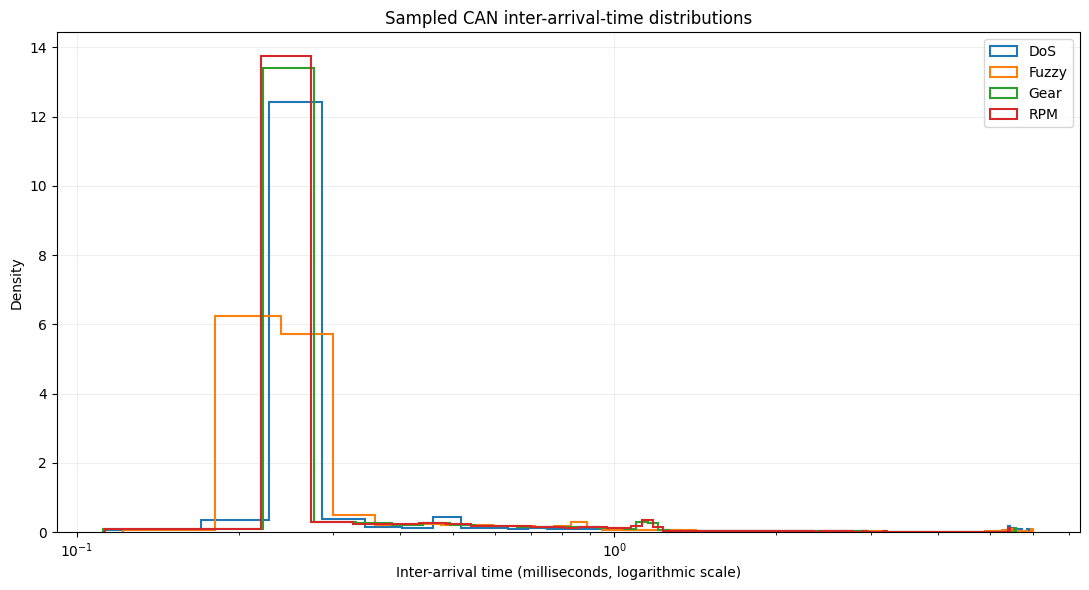

In [19]:
# EDA 8 — Inter-arrival-time distributions

fig, ax = plt.subplots(figsize=(11, 6))

for capture in SOURCE_FILES:
    values = AUDITS[capture]["iat_sample"]
    values = values[(values > 0) & np.isfinite(values)]

    if len(values) == 0:
        continue

    clipped = np.clip(values * 1000.0, 1e-5, np.percentile(values * 1000.0, 99.5))

    ax.hist(
        clipped,
        bins=100,
        density=True,
        histtype="step",
        linewidth=1.5,
        label=capture,
    )

ax.set_xscale("log")
ax.set_title("Sampled CAN inter-arrival-time distributions")
ax.set_xlabel("Inter-arrival time (milliseconds, logarithmic scale)")
ax.set_ylabel("Density")
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "08_inter_arrival_time.png", dpi=180)
plt.show()

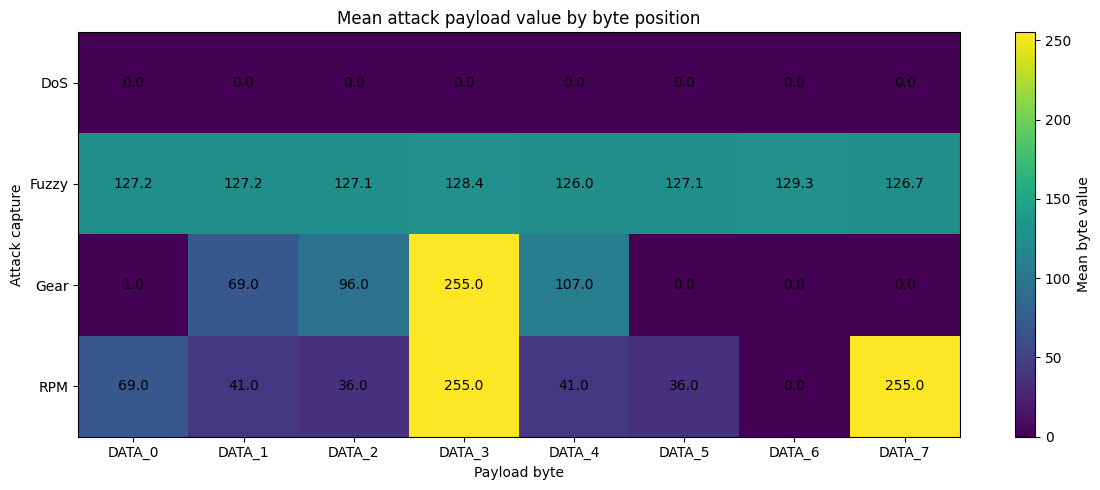

,DATA_0,DATA_1,DATA_2,DATA_3,DATA_4,DATA_5,DATA_6,DATA_7
Capture,,,,,,,,
DoS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Fuzzy,127.194024,127.182669,127.140637,128.447211,125.991036,127.073904,129.253187,126.713944
Gear,1.000000,69.000000,96.000000,255.000000,107.000000,0.000000,0.000000,0.000000
RPM,69.000000,41.000000,36.000000,255.000000,41.000000,36.000000,0.000000,255.000000


In [20]:
# EDA 9 — Attack-only mean payload byte values

payload_mean_rows = []

for capture in SOURCE_FILES:
    attack_sample = eda_sample_df[
        (eda_sample_df["Capture"] == capture)
        & (eda_sample_df["Flag"] == "T")
    ]

    row = {"Capture": capture}

    for byte_index in range(8):
        row[f"DATA_{byte_index}"] = (
            attack_sample[f"DATA_{byte_index}"].mean()
            if len(attack_sample)
            else np.nan
        )

    payload_mean_rows.append(row)

attack_payload_mean_df = pd.DataFrame(payload_mean_rows).set_index("Capture")

fig, ax = plt.subplots(figsize=(12, 5))
image = ax.imshow(attack_payload_mean_df.values, aspect="auto")
ax.set_title("Mean attack payload value by byte position")
ax.set_xlabel("Payload byte")
ax.set_ylabel("Attack capture")
ax.set_xticks(range(8))
ax.set_xticklabels([f"DATA_{i}" for i in range(8)])
ax.set_yticks(range(len(attack_payload_mean_df)))
ax.set_yticklabels(attack_payload_mean_df.index)

for row_index in range(attack_payload_mean_df.shape[0]):
    for column_index in range(attack_payload_mean_df.shape[1]):
        value = attack_payload_mean_df.iloc[row_index, column_index]
        ax.text(
            column_index,
            row_index,
            f"{value:.1f}",
            ha="center",
            va="center",
        )

fig.colorbar(image, ax=ax, label="Mean byte value")
plt.tight_layout()
plt.savefig(PLOT_DIR / "09_attack_payload_heatmap.png", dpi=180)
plt.show()

display(attack_payload_mean_df)

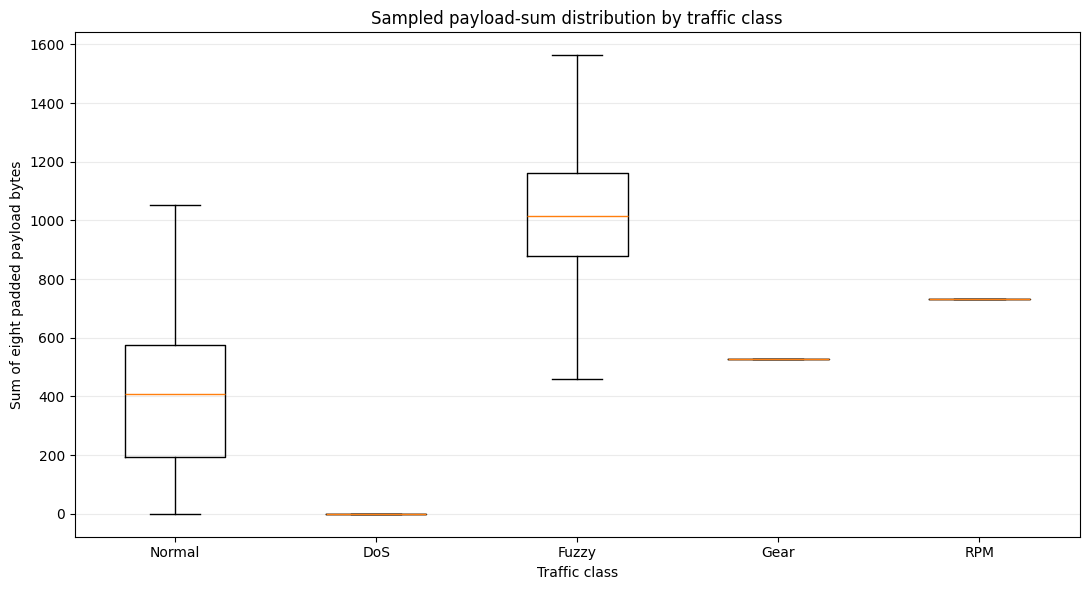

In [21]:
# EDA 10 — Sampled payload sums by traffic class

eda_sample_df["Payload_Sum"] = (
    eda_sample_df[PAYLOAD_COLUMNS].sum(axis=1)
)

classes = ["Normal", "DoS", "Fuzzy", "Gear", "RPM"]
box_data = [
    eda_sample_df.loc[
        eda_sample_df["Traffic_Class"] == class_name,
        "Payload_Sum",
    ].to_numpy()
    for class_name in classes
]

fig, ax = plt.subplots(figsize=(11, 6))
ax.boxplot(box_data, labels=classes, showfliers=False)
ax.set_title("Sampled payload-sum distribution by traffic class")
ax.set_xlabel("Traffic class")
ax.set_ylabel("Sum of eight padded payload bytes")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(PLOT_DIR / "10_payload_sum_by_class.png", dpi=180)
plt.show()

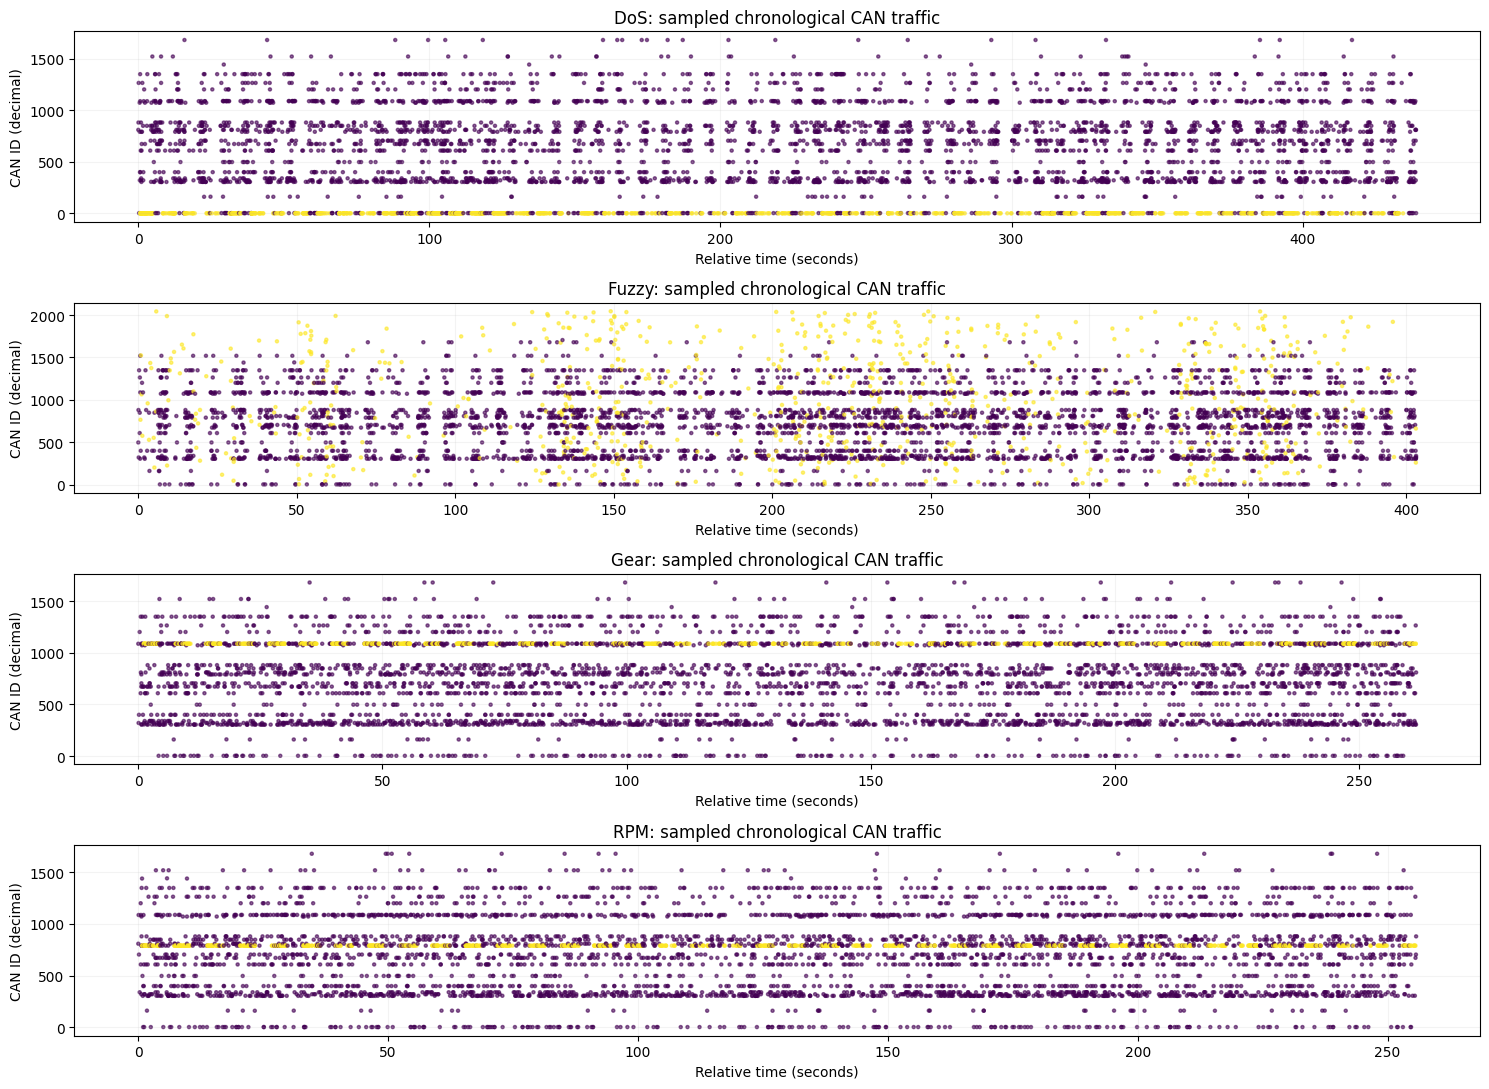

In [22]:
# EDA 11 — Sample chronological traffic timeline for each capture

fig, axes = plt.subplots(4, 1, figsize=(15, 11), sharex=False)

for ax, capture in zip(axes, SOURCE_FILES):
    subset = (
        eda_sample_df[eda_sample_df["Capture"] == capture]
        .sort_values("Timestamp")
        .head(5_000)
        .copy()
    )

    subset["Relative_Time"] = (
        subset["Timestamp"] - subset["Timestamp"].min()
    )

    colours = np.where(subset["Flag"] == "T", 1, 0)

    scatter = ax.scatter(
        subset["Relative_Time"],
        subset["CAN_ID_Decimal"],
        c=colours,
        s=5,
        alpha=0.6,
    )

    ax.set_title(f"{capture}: sampled chronological CAN traffic")
    ax.set_xlabel("Relative time (seconds)")
    ax.set_ylabel("CAN ID (decimal)")
    ax.grid(alpha=0.15)

plt.tight_layout()
plt.savefig(PLOT_DIR / "11_chronological_timeline.png", dpi=180)
plt.show()

# Part B — Week 2 Findings and Responsible Interpretation

## Main findings to discuss in GitHub

- All four source captures contain substantially more legitimate than injected messages.
- DLC is usually eight, but shorter frames exist and justify a DLC-aware parser.
- DoS traffic is expected to concentrate strongly around a dominant CAN ID.
- Fuzzy traffic is expected to introduce broader CAN-ID and payload variability.
- Gear and RPM spoofing are expected to alter characteristic payload positions.
- Timestamp order is essential because later sequence models depend on temporal continuity.

## Important limitations

1. The benchmark comes from one vehicle platform.
2. Normal frames are obtained from legitimate traffic inside attack captures.
3. Raw class prevalence is imbalanced.
4. A high-frequency CAN ID may be a dataset-specific shortcut.
5. Initial EDA does not demonstrate model generalisation.
6. Raw CAN data and large derived files should remain outside normal Git commits.

In [23]:
# 8. Export Week 2 audit evidence and create a downloadable ZIP

payload_stats_rows = []

for capture in SOURCE_FILES:
    for byte_index in range(8):
        payload_stats_rows.append({
            "Capture": capture,
            "Byte_Position": byte_index,
            "Mean": float(AUDITS[capture]["payload_mean"][byte_index]),
            "Std": float(AUDITS[capture]["payload_std"][byte_index]),
            "Valid_Value_Count": int(
                AUDITS[capture]["payload_valid_count"][byte_index]
            ),
        })

payload_stats_df = pd.DataFrame(payload_stats_rows)
payload_stats_df.to_csv(
    REPORT_DIR / "week02_payload_statistics.csv",
    index=False,
)

week2_summary = {
    "project": "AutoSPECTRA",
    "week": 2,
    "scope": "Dataset acquisition, DLC-aware parsing, audit and initial EDA",
    "dataset": "HCRL Car-Hacking Dataset",
    "captures": list(SOURCE_FILES),
    "models_trained": False,
    "windowing_completed": False,
    "final_split_completed": False,
    "next_week": (
        "64-frame windows, source-aware chronological splitting, "
        "leakage controls and feature representations"
    ),
    "capture_summary": summary_df.to_dict(orient="records"),
}

with (REPORT_DIR / "week02_summary.json").open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(week2_summary, handle, indent=2)

zip_path = Path("/kaggle/working/AutoSPECTRA_Week02_Evidence.zip")

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as archive:
    for file_path in OUTPUT_DIR.rglob("*"):
        if file_path.is_file():
            archive.write(
                file_path,
                file_path.relative_to(OUTPUT_DIR),
            )

print("=" * 90)
print("AUTOSPECTRA WEEK 2 AUDIT COMPLETE")
print("=" * 90)
print("Reports:", REPORT_DIR)
print("Plots:", PLOT_DIR)
print("Download ZIP:", zip_path)
print("Models trained in Week 2: No")
print("Next technical step: Week 3 windowing, split and feature representations")

AUTOSPECTRA WEEK 2 AUDIT COMPLETE
Reports: /kaggle/working/autospectra_week02_outputs/reports
Plots: /kaggle/working/autospectra_week02_outputs/plots
Download ZIP: /kaggle/working/AutoSPECTRA_Week02_Evidence.zip
Models trained in Week 2: No
Next technical step: Week 3 windowing, split and feature representations


# GitHub Push Information

## Recommended repository path

```text
notebooks/week02/autospectra_week02_dataset_audit_eda.ipynb
```

## Owner

**Amit Das** — Data pipeline and repository integration

## Review contributions

- **Aahmad Sayeed:** review plots and CAN recurrence requirements.
- **Maheswari Kamireddy:** confirm chronological and sequence requirements.
- **Miftha Thahniyath:** confirm metadata required by future incident reports.
- **Nagireddy Nakka:** confirm limitations and responsible-data statements.

## Commit message

```text
Notebook: add Week 2 CAN dataset audit and initial EDA
```

## Pull-request title

```text
Week 2: Add HCRL data parser audit and initial EDA
```

## Week 3 boundary

Do not add the final model metrics to this Week 2 pull request. Week 3 should introduce:

- 64-frame non-overlapping windows;
- source-aware and class-aware chronological partitions;
- leakage and class-support tests;
- 24 tabular features;
- `64 × 11` sequences;
- `64 × 64` recurrence images.

# Week 2 GitHub Evidence


## Recommended Branch

```text
week2/dataset-audit-eda
```

## Commit Message

```text
Notebook: add Week 2 HCRL dataset audit and initial EDA
```

## Pull-Request Title

```text
Week 2: Add DLC-aware parser dataset audit and initial EDA
```

## Pull-Request Summary

```text
This pull request adds the Week 2 AutoSPECTRA dataset foundation:
- HCRL source-file discovery
- chunked DLC-aware CAN parsing
- hexadecimal CAN-ID and payload conversion
- normal and injected-message audit
- DLC and CAN-ID analysis
- payload and timing visualisations
- responsible-data and limitation statements
- team contribution evidence

No raw dataset, model file, processed cache or deployment ZIP is included.
```

## Review Responsibilities

| Reviewer | Review Focus |
|---|---|
| Aahmad Sayeed | EDA figures and recurrence-image requirements |
| Maheswari Kamireddy | Chronological ordering and sequence-ready structure |
| Miftha Thahniyath | Metadata required for reporting and Flask display |
| Nagireddy Nakka | Limitations, responsible-data handling and documentation |